In [ ]:
%run -i ../../python_scripts/nb_setup.py

#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [2]:
sgp_df_SR = pickle.load(open("sgp_set_cnn", "rb"))
print(
    "N =",
    sgp_df_SR.shape[0],
    "Proportion of 1s: ",
    np.round(sgp_df_SR.y_true.sum() / sgp_df_SR.shape[0], 2),
)
sgp_df_SR.head(3)

N = 40000 Proportion of 1s:  0.1


,y_true,y_pred,kappa
0,0.0,0.0,0.968736
1,0.0,1.0,0.870544
2,0.0,0.0,0.882295


In [3]:
sgp_df_MCD = pickle.load(open("sgp_set_cnn_MCD", "rb"))
sgp_df_MCD.head(3)

,y_true,y_pred,kappa
0,0.0,0.0,-0.000774
1,0.0,1.0,-0.004592
2,0.0,0.0,-0.004616


In [4]:
num_targets = 5000  # number of targets r* to consider when drawing metric/coverage of metric/theta curves
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grids
theta_min_MCD, theta_max_MCD = (-0.05, 0)
metric_targets = np.linspace(0, 1, num=num_targets)

Plot lines configuration (cosmetic) 

In [5]:
lines_list_1_SR, lines_list_2_SR, lines_list_1_MCD, lines_list_2_MCD, lines_list_2 = (
    lines()
)

## 1. __Unconditional risks__

### 1.1. __0/1 risk__

In [6]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=0
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=0
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

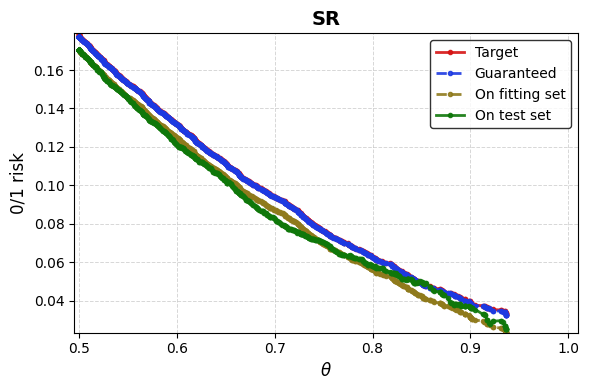

In [7]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

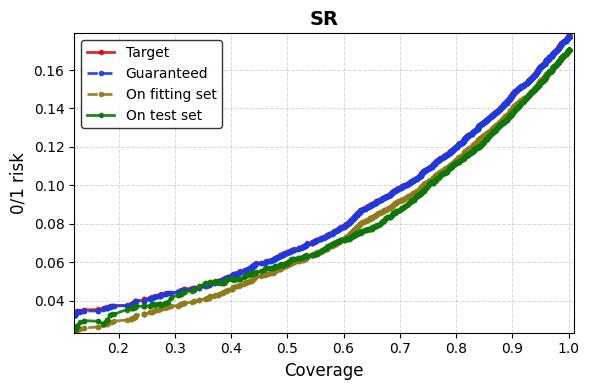

In [8]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

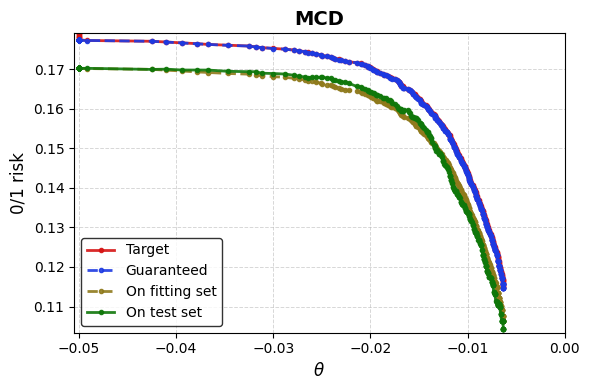

In [9]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

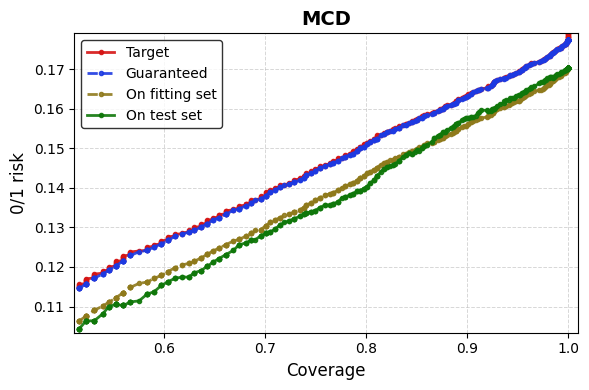

In [10]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

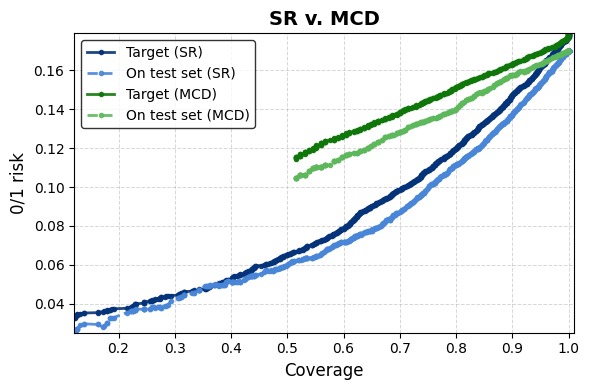

In [11]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 1.2. __FP risk__

In [12]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=1
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=1)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FP",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

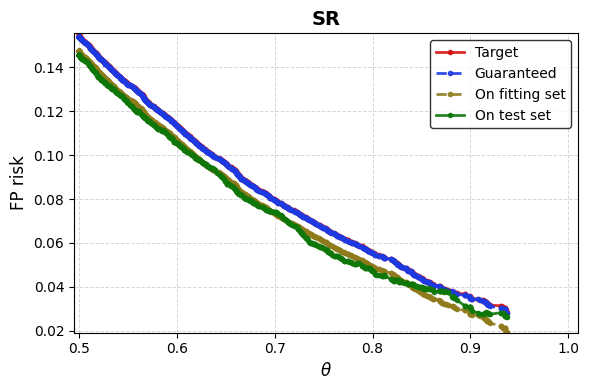

In [13]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

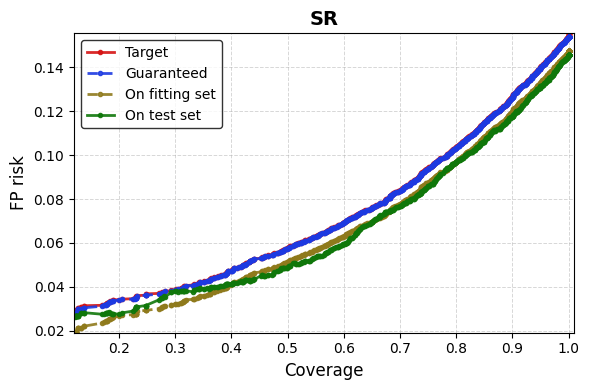

In [14]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

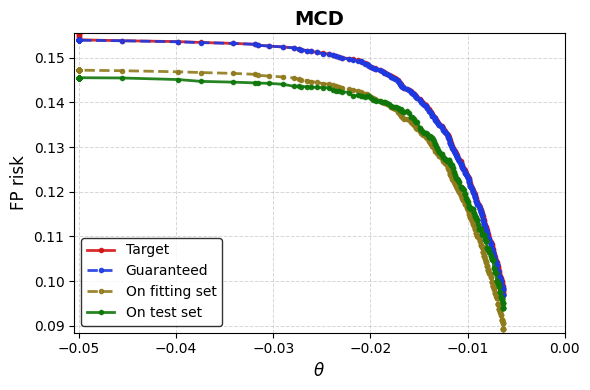

In [15]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

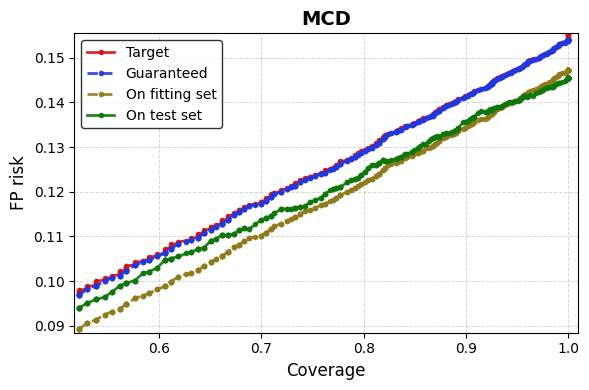

In [16]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

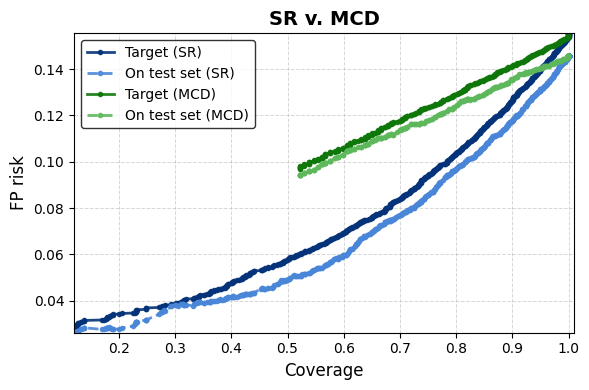

In [17]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 1.3. __FN risk__

In [18]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=2
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=2)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FN",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FN",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

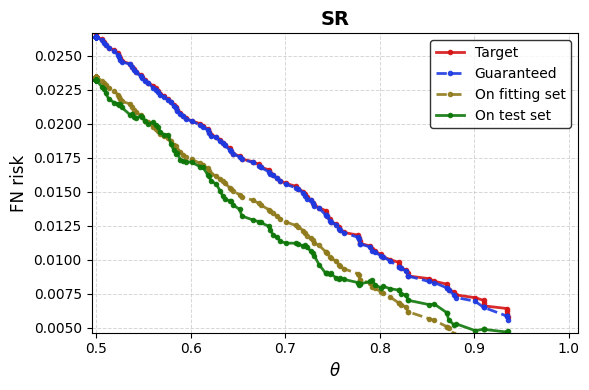

In [19]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

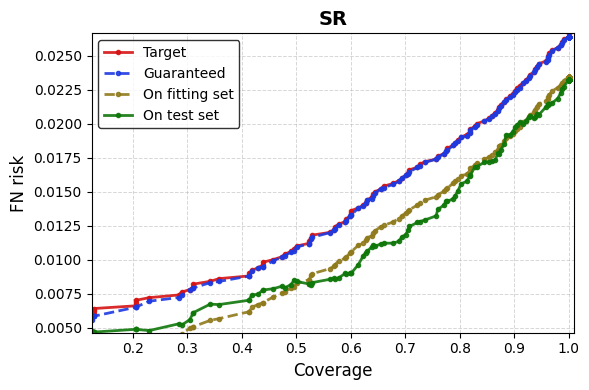

In [20]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

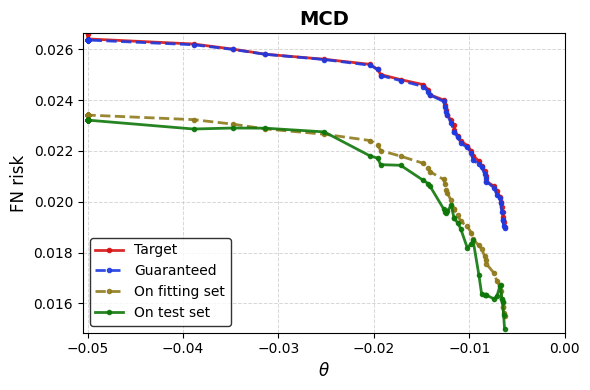

In [21]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

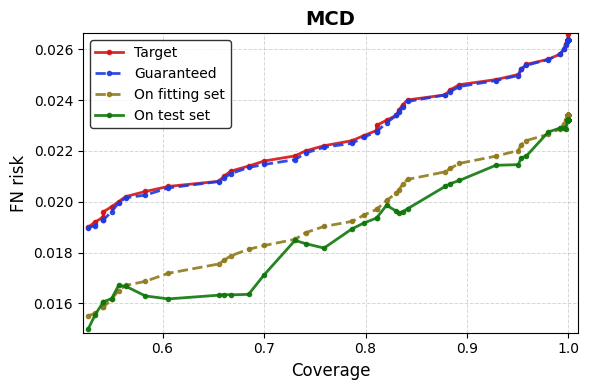

In [22]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

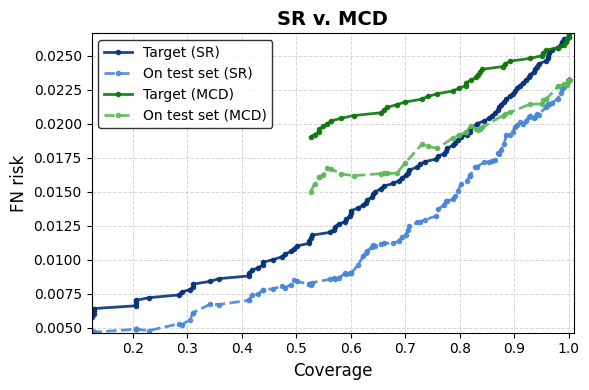

In [23]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

## __2. Conditional metrics__

### 2.1. __FPR__

In [24]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=3
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=3)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FPR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FPR",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

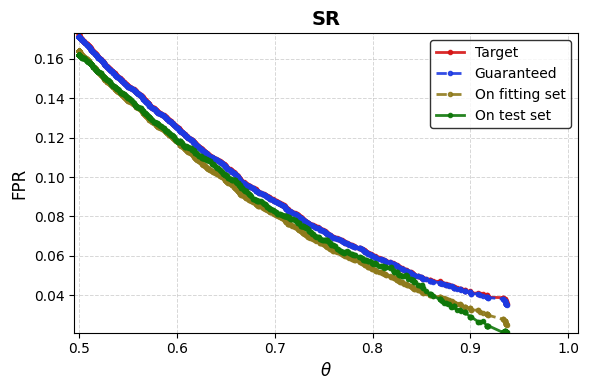

In [25]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

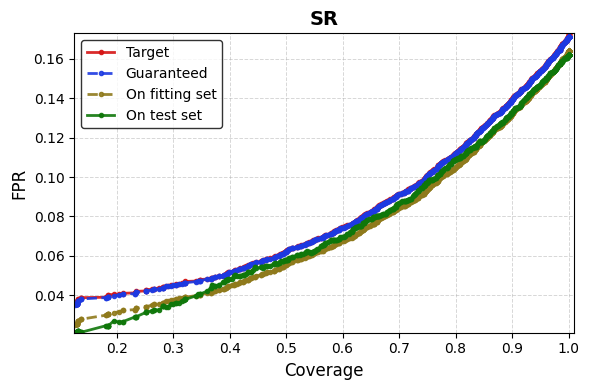

In [26]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

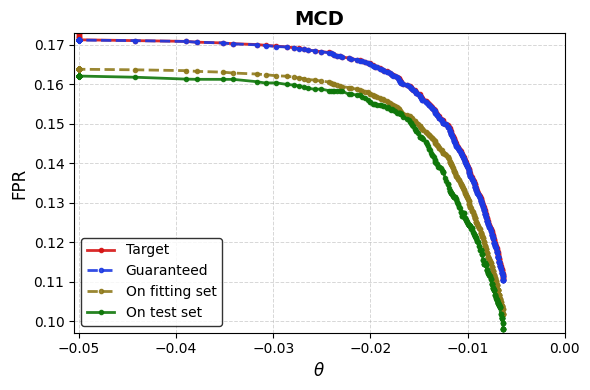

In [27]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

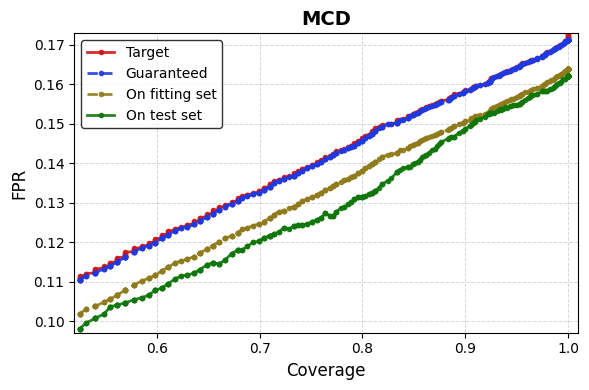

In [28]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

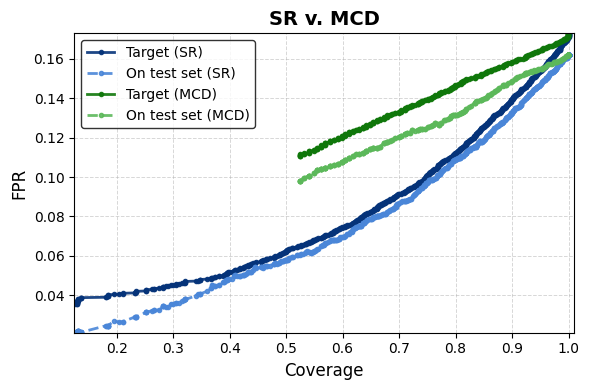

In [29]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 2.2. __FNR__

In [30]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=4
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=4)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FNR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FNR",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

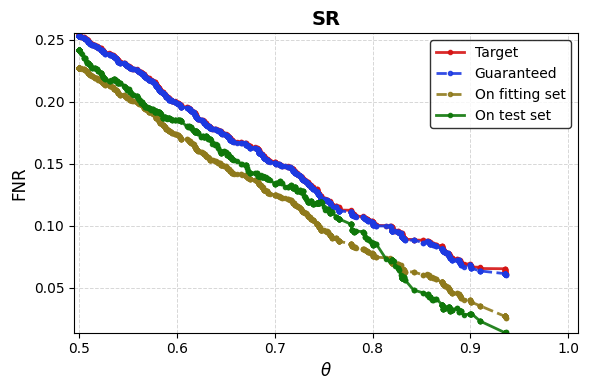

In [31]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

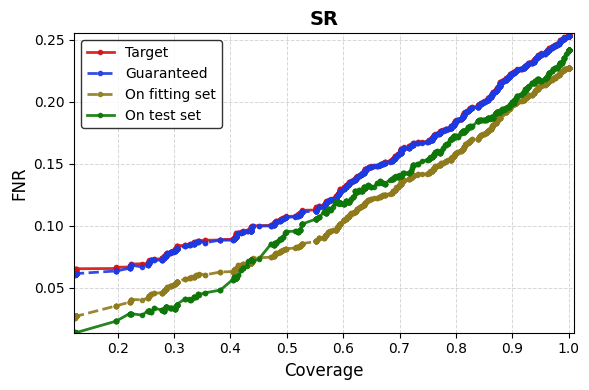

In [32]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

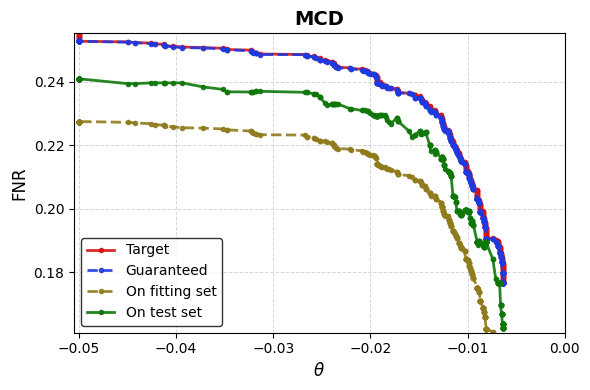

In [33]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

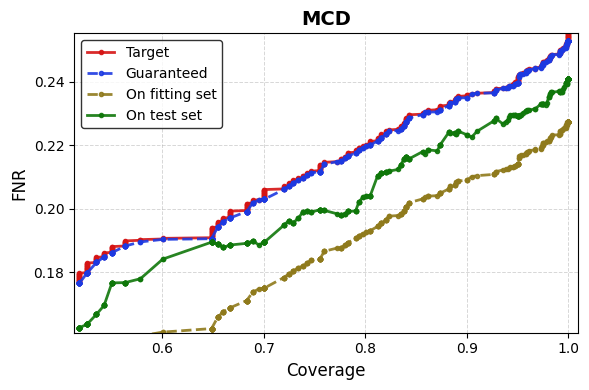

In [34]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

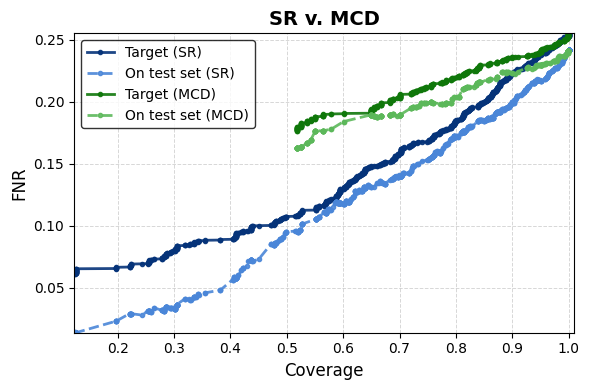

In [35]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 2.3. __PPV__

In [36]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=5
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=5)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="PPV",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="PPV",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

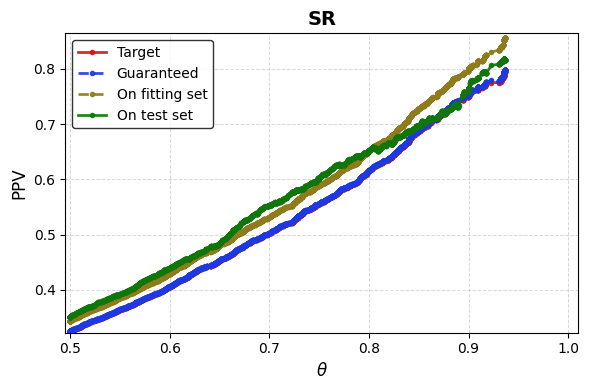

In [37]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

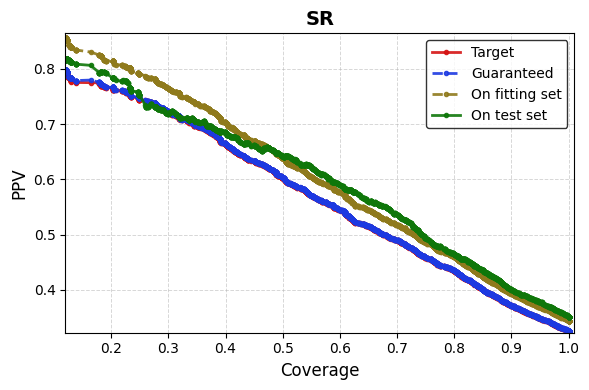

In [38]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

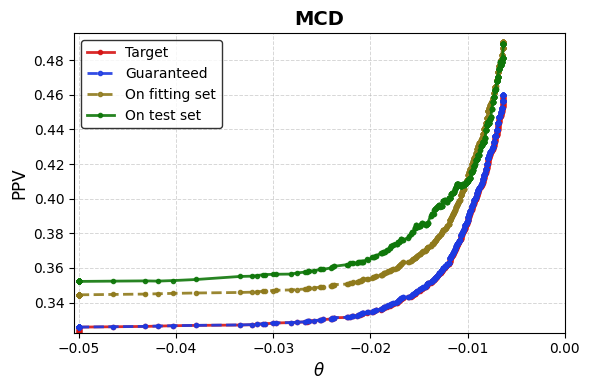

In [39]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

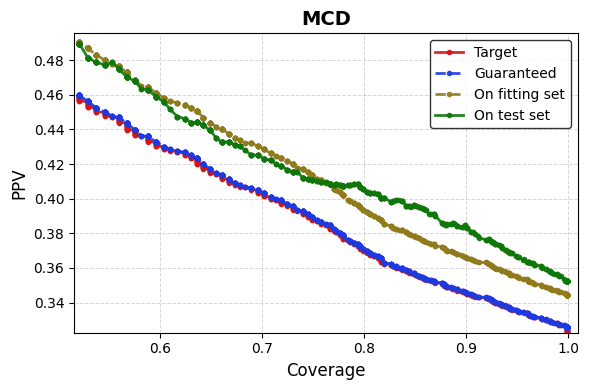

In [40]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

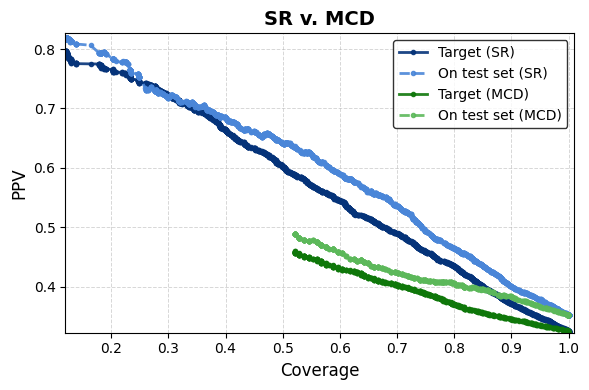

In [41]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_SR.test_coverage), max(results_MCD.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.metric_bound), min(results_SR.metric_bound)),
        1.01 * max(max(results_MCD.test_metric), max(results_SR.test_metric)),
    ],
    title="SR v. MCD",
)

### 2.4. __SE__

In [42]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=6
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=6)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SE",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="SE",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

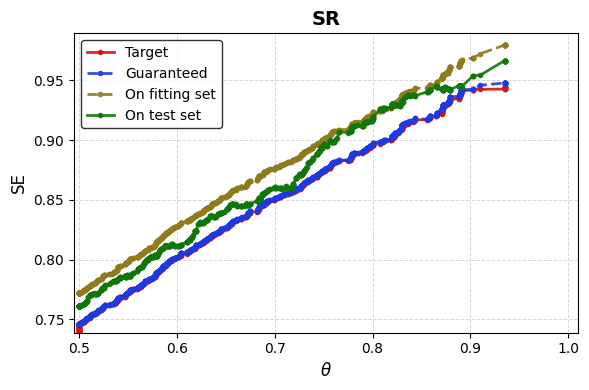

In [43]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

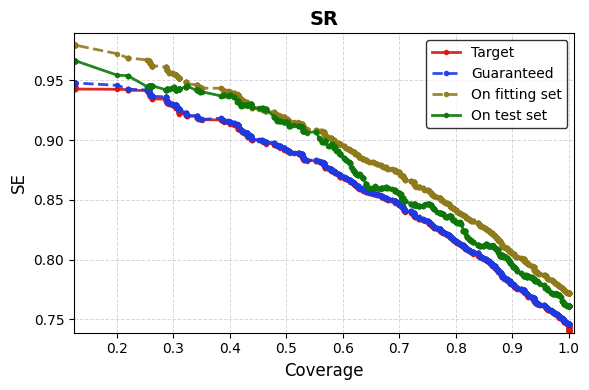

In [44]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

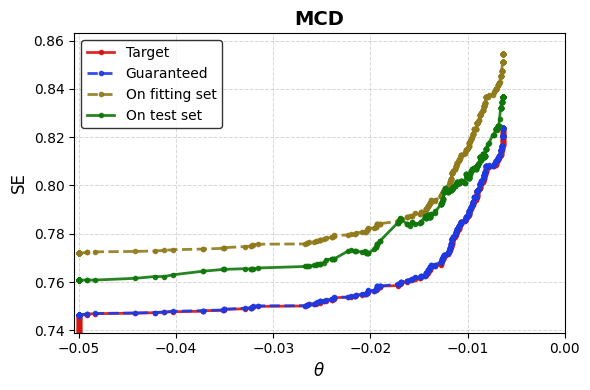

In [45]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

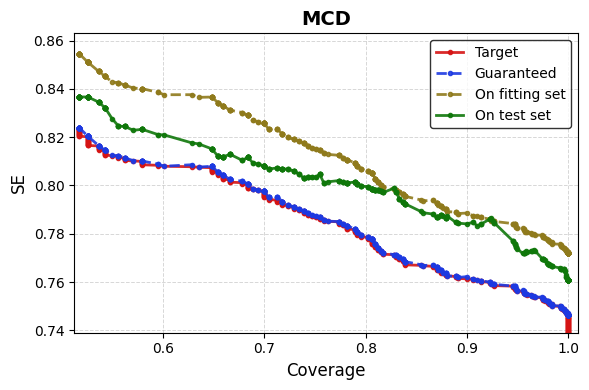

In [46]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

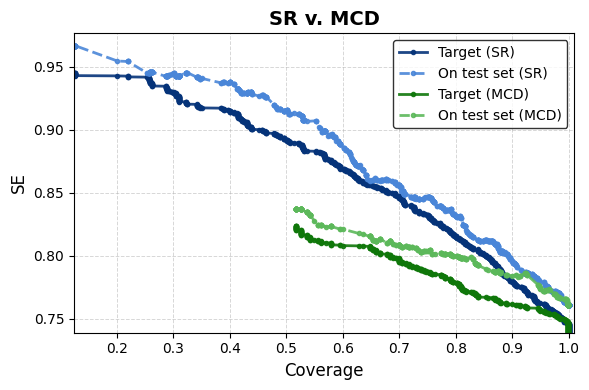

In [47]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_SR.test_coverage), max(results_MCD.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.metric_bound), min(results_SR.metric_bound)),
        1.01 * max(max(results_MCD.test_metric), max(results_SR.test_metric)),
    ],
    title="SR v. MCD",
)

### 2.5. __SP__

In [48]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=7
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=7)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="SP",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

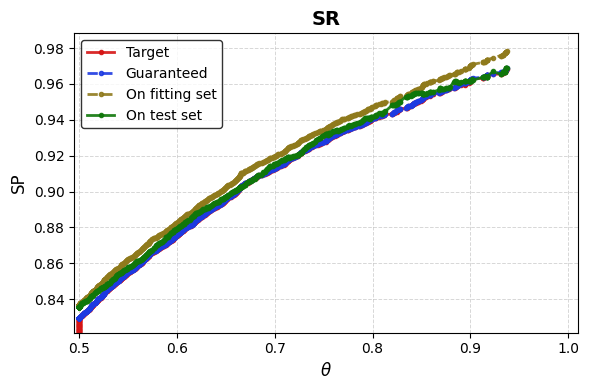

In [49]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

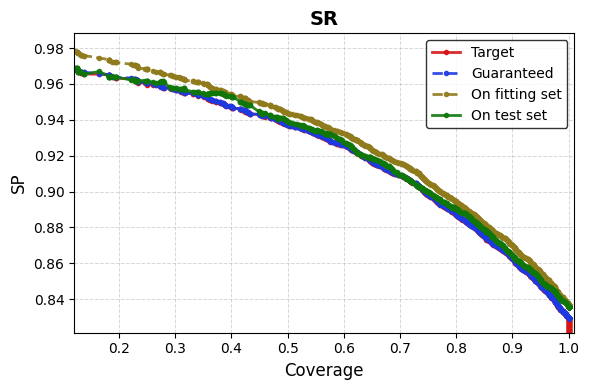

In [50]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

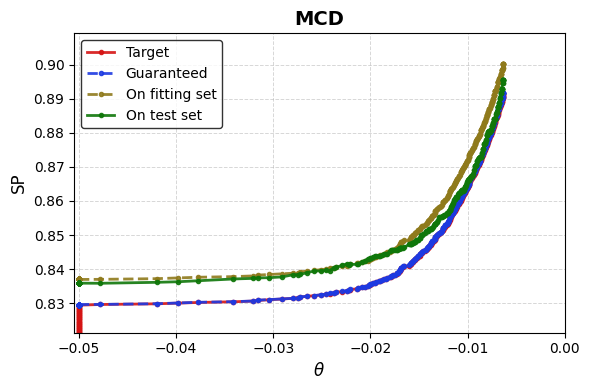

In [51]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

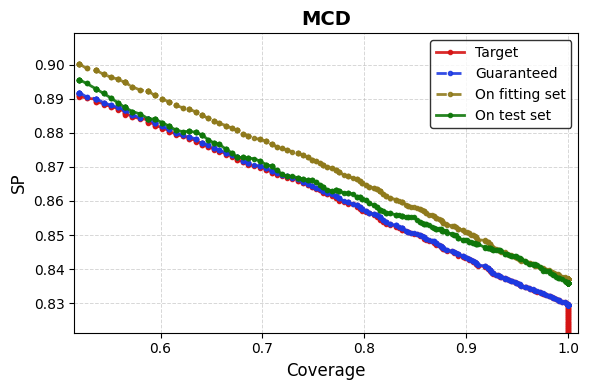

In [52]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

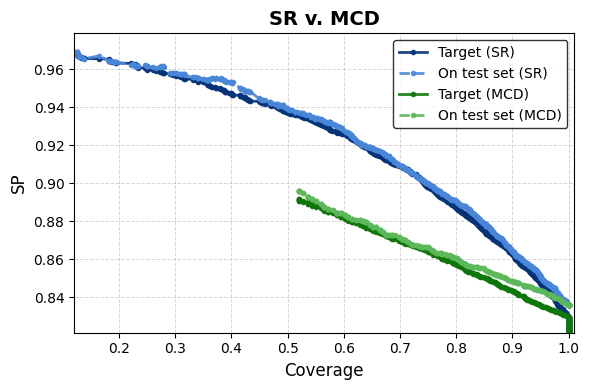

In [53]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_SR.test_coverage), max(results_MCD.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.metric_bound), min(results_SR.metric_bound)),
        1.01 * max(max(results_MCD.test_metric), max(results_SR.test_metric)),
    ],
    title="SR v. MCD",
)